In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LassoCV, LogisticRegression, LinearRegression
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.api as sm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers, constraints, initializers

tf.random.set_seed(42)
np.random.seed(42)
print('Libraries loaded.')
print(f'TensorFlow version: {tf.__version__}')

Libraries loaded.
TensorFlow version: 2.21.0


## Data Loading & Feature Engineering

In [2]:
# Load all data sources
consol = pd.read_csv('consolidated_db.csv', parse_dates=['trade_date'])
dam = pd.read_csv('uploads/da_model_dataset.csv', parse_dates=['date'])
eua = pd.read_csv('uploads/eua_front_year.csv', parse_dates=['trade_date'])

dam.rename(columns={'date': 'trade_date'}, inplace=True)
dam_cols = [c for c in dam.columns if c not in consol.columns and c != 'trade_date']

master = consol.merge(dam[['trade_date'] + dam_cols], on='trade_date', how='left')
master = master.merge(
    eua[['trade_date', 'volume', 'open_interest']].rename(
        columns={'volume': 'eua_volume', 'open_interest': 'eua_oi'}),
    on='trade_date', how='left')

# Feature Engineering
energy_base = ['lag_r_EUA', 'lag_r_TTF', 'lag_r_Coal', 'lag_r_Brent',
               'lag_r_Power', 'lag_d_CDS', 'lag_d_CSS']
dam_features = [c for c in dam_cols if c != 'lag_cot_date' and c != 'lag_r_EUA']
linear_candidates = list(dict.fromkeys(energy_base + dam_features))
linear_candidates = [c for c in linear_candidates if c in master.columns]

energy_nl = []
for col in ['lag_r_TTF', 'lag_r_Coal', 'lag_r_Brent', 'lag_r_Power']:
    if col in master.columns:
        master[f'{col}_sq'] = master[col] ** 2
        energy_nl.append(f'{col}_sq')
if all(c in master.columns for c in ['Coal', 'TTF']):
    master['lag_coal_gas_ratio'] = (master['Coal'] / master['TTF'].replace(0, np.nan)).shift(1)
    energy_nl.append('lag_coal_gas_ratio')
if all(c in master.columns for c in ['Power', 'TTF', 'Coal']):
    master['lag_spark_spread'] = (master['Power'] - master['TTF']).shift(1)
    master['lag_dark_spread'] = (master['Power'] - master['Coal']).shift(1)
    energy_nl.extend(['lag_spark_spread', 'lag_dark_spread'])

auction_nl = []
for col in ['lag_eu_auction_premium', 'lag_eu_cover_ffill_surp']:
    if col in master.columns:
        master[f'{col}_sq'] = master[col] ** 2
        auction_nl.append(f'{col}_sq')

cot_nl = []
for col in ['lag_IF_net_z26', 'lag_CU_net_z26', 'lag_IF_concentration']:
    if col in master.columns:
        master[f'{col}_sq'] = master[col] ** 2
        cot_nl.append(f'{col}_sq')
if all(c in master.columns for c in ['lag_IF_net_z26', 'lag_CU_net_z26']):
    master['lag_spec_comm_imbalance'] = master['lag_IF_net_z26'] - master['lag_CU_net_z26']
    cot_nl.append('lag_spec_comm_imbalance')
if 'lag_IF_net_z26' in master.columns:
    master['lag_crowded_spec'] = (master['lag_IF_net_z26'].abs() > 1.5).astype(int)
    cot_nl.append('lag_crowded_spec')

opts_nl = []
for col in ['lag_atm_iv', 'lag_rr_25', 'lag_vrp', 'lag_rv_ratio']:
    if col in master.columns:
        master[f'{col}_sq'] = master[col] ** 2
        opts_nl.append(f'{col}_sq')
if 'lag_atm_iv' in master.columns:
    iv_p75 = master['lag_atm_iv'].rolling(252, min_periods=60).quantile(0.75)
    master['lag_high_iv_regime'] = (master['lag_atm_iv'] > iv_p75).astype(int)
    opts_nl.append('lag_high_iv_regime')

cross_nl = []
for a, b, name in [
    ('lag_r_TTF', 'lag_IF_net_z26', 'lag_TTF_x_IF_z26'),
    ('lag_r_TTF', 'lag_atm_iv', 'lag_TTF_x_IV'),
    ('lag_r_Coal', 'lag_CU_net_z26', 'lag_Coal_x_CU_z26'),
    ('lag_eu_auction_premium', 'lag_IF_net_z26', 'lag_auc_x_IF'),
    ('lag_IF_net_z26', 'lag_atm_iv', 'lag_IF_x_IV'),
]:
    if all(c in master.columns for c in [a, b]):
        master[name] = master[a] * master[b]
        cross_nl.append(name)

all_nl_features = energy_nl + auction_nl + cot_nl + opts_nl + cross_nl
all_candidates = linear_candidates + all_nl_features
for c in all_candidates:
    if c in master.columns:
        master[c] = master[c].replace([np.inf, -np.inf], np.nan)

target = 'r_EUA'
coverage = master[all_candidates].notna().mean()
all_candidates = [c for c in all_candidates if coverage[c] >= 0.70]
squared_features = [c for c in all_candidates if '_sq' in c]
unsquared_features = [c for c in all_candidates if '_sq' not in c]

model_data = master[[target, 'trade_date'] + all_candidates].dropna().reset_index(drop=True)
print(f'Model matrix: {len(model_data)} days x {len(all_candidates)} features')
print(f'  Squared: {len(squared_features)},  Unsquared: {len(unsquared_features)}')

Model matrix: 963 days x 69 features
  Squared: 13,  Unsquared: 56


## Helper: CNN Autoencoder Builder
This function is used throughout all three parts. We parameterise it so we can swap normalization, initialization, and clipping strategies.

In [3]:
def build_cnn_autoencoder(input_dim, encoded_dim=8, name_prefix='',
                         kernel_initializer='glorot_uniform',
                         use_spring_norm=False, spring_k_init=1.0,
                         use_weight_norm=False,
                         use_batch_norm=False,
                         use_layer_norm=False,
                         kernel_constraint_val=None):
    
    k_constraint = constraints.MaxNorm(kernel_constraint_val) if kernel_constraint_val else None

    inp = layers.Input(shape=(input_dim,), name=f'{name_prefix}_input')
    x = layers.Reshape((input_dim, 1))(inp)

    # ENCODER
    x = layers.Conv1D(32, kernel_size=3, padding='same', activation='relu',
                      kernel_initializer=kernel_initializer,
                      kernel_constraint=k_constraint,
                      name=f'{name_prefix}_conv1')(x)
    if use_batch_norm:
        x = layers.BatchNormalization(name=f'{name_prefix}_bn1')(x)
    if use_layer_norm:
        x = layers.LayerNormalization(name=f'{name_prefix}_ln1')(x)

    x = layers.Conv1D(16, kernel_size=3, padding='same', activation='relu',
                      kernel_initializer=kernel_initializer,
                      kernel_constraint=k_constraint,
                      name=f'{name_prefix}_conv2')(x)
    if use_batch_norm:
        x = layers.BatchNormalization(name=f'{name_prefix}_bn2')(x)
    if use_layer_norm:
        x = layers.LayerNormalization(name=f'{name_prefix}_ln2')(x)

    x = layers.GlobalAveragePooling1D(name=f'{name_prefix}_pool')(x)

    # Spring normalization (if enabled)
    if use_spring_norm:
        x = SpringNormalization(spring_k_init=spring_k_init,
                                name=f'{name_prefix}_spring')(x)

    encoded = layers.Dense(encoded_dim, activation='relu',
                           kernel_initializer=kernel_initializer,
                           kernel_constraint=k_constraint,
                           name=f'{name_prefix}_encoded')(x)

    # DECODER
    d = layers.Dense(16, activation='relu',
                     kernel_initializer=kernel_initializer,
                     name=f'{name_prefix}_dec1')(encoded)
    d = layers.Dense(input_dim, activation='linear',
                     name=f'{name_prefix}_output')(d)

    autoencoder = Model(inp, d, name=f'{name_prefix}_autoencoder')
    encoder = Model(inp, encoded, name=f'{name_prefix}_encoder')
    return autoencoder, encoder

## Spring Normalization — Custom Layer
 Here each weight as attached to a spring. The spring's natural position is the normalized value. But if the network finds that a feature is more useful at its original scale, the spring *stretches* — the weight moves away from the normalized position. When the feature isn't useful, the spring *contracts* back to the normalized position.


In [4]:
class SpringNormalization(layers.Layer):
    
    def __init__(self, spring_k_init=1.0, **kwargs):
        super().__init__(**kwargs)
        self.spring_k_init = spring_k_init

    def build(self, input_shape):
        n_features = input_shape[-1]
        # Spring constant per feature — starts at spring_k_init
        # Higher init = more normalisation initially, network can relax it
        self.spring_k = self.add_weight(
            shape=(n_features,),
            name='spring_k',
            initializer=tf.initializers.Constant(self.spring_k_init),
            trainable=True
        )
        # Learnable scale — can amplify recovered features
        self.scale = self.add_weight(
            shape=(n_features,),
            name='scale',
            initializer='ones', trainable=True
        )
        # Learnable bias — can shift features
        self.bias = self.add_weight(
            shape=(n_features,),
            name='bias',
            initializer='zeros', trainable=True
        )

    def call(self, inputs, training=None):
        # Compute batch statistics
        mean = tf.reduce_mean(inputs, axis=0, keepdims=True)
        var = tf.math.reduce_variance(inputs, axis=0, keepdims=True) + 1e-8
        x_norm = (inputs - mean) / tf.sqrt(var)

        # Spring interpolation
        alpha = tf.sigmoid(self.spring_k)  # 0 to 1 per feature
        x_spring = alpha * x_norm + (1.0 - alpha) * inputs

        # Learnable scale and shift (recovery mechanism)
        return self.scale * x_spring + self.bias

    def get_config(self):
        config = super().get_config()
        config.update({'spring_k_init': self.spring_k_init})
        return config

print('SpringNormalization layer defined.')

SpringNormalization layer defined.


In [5]:
#  different minimum training window sizes

y_all = model_data[target].values
X_all = model_data[all_candidates].values
X_unsq_all = model_data[unsquared_features].values

test_window = 60
step_size = 40
alphas = np.logspace(-6, -1, 30)

window_sizes = [150, 250, 350, 500, 650, 750]
window_results = {}

for min_train in window_sizes:
    # Build iterations for this window size
    iterations = []
    for test_start in range(min_train, len(y_all) - test_window + 1, step_size):
        test_end = test_start + test_window
        iterations.append((test_start, test_end))

    if len(iterations) < 3:
        print(f'min_train={min_train}: Only {len(iterations)} iterations, skipping.')
        continue

    print(f'\nmin_train = {min_train}: {len(iterations)} iterations')

    # AR(1)
    ar_wrs = []
    for test_start, test_end in iterations:
        X_tr, y_tr = X_all[:test_start], y_all[:test_start]
        X_te, y_te = X_all[test_start:test_end], y_all[test_start:test_end]
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)
        ar_idx = all_candidates.index('lag_r_EUA')
        m_ar = sm.OLS(y_tr, sm.add_constant(X_tr_s[:, ar_idx:ar_idx+1])).fit()
        p_ar = m_ar.predict(sm.add_constant(X_te_s[:, ar_idx:ar_idx+1]))
        ar_wrs.append(((p_ar > 0) == (y_te > 0)).mean())

    # Lasso
    lasso_wrs = []
    for test_start, test_end in iterations:
        X_tr, y_tr = X_all[:test_start], y_all[:test_start]
        X_te, y_te = X_all[test_start:test_end], y_all[test_start:test_end]
        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)
        tscv = TimeSeriesSplit(n_splits=3)
        lasso = LassoCV(alphas=alphas, cv=tscv, max_iter=20000, random_state=42)
        lasso.fit(X_tr_s, y_tr)
        p_l = lasso.predict(X_te_s)
        lasso_wrs.append(((p_l > 0) == (y_te > 0)).mean())

    # Pool 4: CNN Autoencoder on unsquared features 
    pool4_wrs = []
    for test_start, test_end in iterations:
        X_tr_u = X_unsq_all[:test_start]
        X_te_u = X_unsq_all[test_start:test_end]
        y_tr = y_all[:test_start]
        y_te = y_all[test_start:test_end]

        scaler_u = StandardScaler()
        X_tr_us = scaler_u.fit_transform(X_tr_u)
        X_te_us = scaler_u.transform(X_te_u)

        tf.random.set_seed(42)
        np.random.seed(42)
        ae, enc = build_cnn_autoencoder(len(unsquared_features), encoded_dim=8, name_prefix='p4')
        ae.compile(optimizer='adam', loss='mse')
        ae.fit(X_tr_us, X_tr_us, epochs=100, batch_size=32, verbose=0, validation_split=0.1)

        enc_tr = enc.predict(X_tr_us, verbose=0)
        enc_te = enc.predict(X_te_us, verbose=0)

        lr = LinearRegression()
        lr.fit(enc_tr, y_tr)
        p4 = lr.predict(enc_te)
        pool4_wrs.append(((p4 > 0) == (y_te > 0)).mean())

    window_results[min_train] = {
        'n_iters': len(iterations),
        'AR1_mean': np.mean(ar_wrs), 'AR1_std': np.std(ar_wrs),
        'Lasso_mean': np.mean(lasso_wrs), 'Lasso_std': np.std(lasso_wrs),
        'Pool4_mean': np.mean(pool4_wrs), 'Pool4_std': np.std(pool4_wrs),
    }
    print(f'  AR(1):  {np.mean(ar_wrs):.2%} ± {np.std(ar_wrs):.2%}')
    print(f'  Lasso:  {np.mean(lasso_wrs):.2%} ± {np.std(lasso_wrs):.2%}')
    print(f'  Pool 4: {np.mean(pool4_wrs):.2%} ± {np.std(pool4_wrs):.2%}')

print('\nDone! All window sizes tested.')


min_train = 150: 19 iterations
  AR(1):  52.37% ± 5.78%
  Lasso:  51.75% ± 5.28%
  Pool 4: 53.33% ± 6.35%

min_train = 250: 17 iterations
  AR(1):  50.20% ± 5.20%
  Lasso:  48.53% ± 4.27%
  Pool 4: 52.84% ± 8.36%

min_train = 350: 14 iterations
  AR(1):  51.67% ± 5.91%
  Lasso:  50.48% ± 4.25%
  Pool 4: 51.19% ± 7.57%

min_train = 500: 11 iterations
  AR(1):  48.64% ± 4.60%
  Lasso:  47.12% ± 5.60%
  Pool 4: 50.76% ± 6.68%

min_train = 650: 7 iterations
  AR(1):  50.24% ± 3.01%
  Lasso:  47.14% ± 5.32%
  Pool 4: 49.76% ± 4.12%

min_train = 750: 4 iterations
  AR(1):  49.17% ± 2.50%
  Lasso:  48.33% ± 4.25%
  Pool 4: 52.50% ± 7.22%

Done! All window sizes tested.


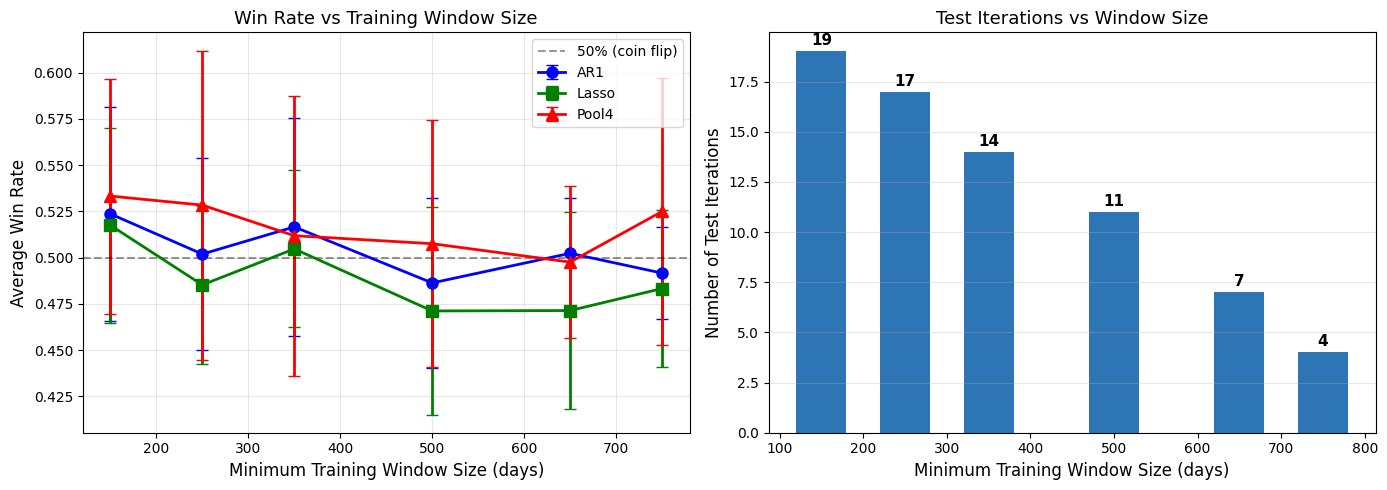


EMPIRICAL WINDOW SELECTION RESULTS
  Window | Iters |        AR(1) |        Lasso |   Pool 4 CNN
---------------------------------------------------------------------------
     150 |    19 | 52.37% ± 5.78% | 51.75% ± 5.28% | 53.33% ± 6.35%
     250 |    17 | 50.20% ± 5.20% | 48.53% ± 4.27% | 52.84% ± 8.36%
     350 |    14 | 51.67% ± 5.91% | 50.48% ± 4.25% | 51.19% ± 7.57%
     500 |    11 | 48.64% ± 4.60% | 47.12% ± 5.60% | 50.76% ± 6.68%
     650 |     7 | 50.24% ± 3.01% | 47.14% ± 5.32% | 49.76% ± 4.12%
     750 |     4 | 49.17% ± 2.50% | 48.33% ± 4.25% | 52.50% ± 7.22%

Best window for Pool 4: min_train = 150 (53.33% avg WR)


In [6]:
# Win Rate vs Training Window Size

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sizes = sorted(window_results.keys())

# Left: Mean Win Rate
ax = axes[0]
for model, color, marker in [('AR1', 'blue', 'o'), ('Lasso', 'green', 's'), ('Pool4', 'red', '^')]:
    means = [window_results[s][f'{model}_mean'] for s in sizes]
    stds = [window_results[s][f'{model}_std'] for s in sizes]
    ax.errorbar(sizes, means, yerr=stds, marker=marker, color=color, label=model,
                capsize=4, linewidth=2, markersize=8)
ax.axhline(0.5, color='black', linestyle='--', alpha=0.4, label='50% (coin flip)')
ax.set_xlabel('Minimum Training Window Size (days)', fontsize=12)
ax.set_ylabel('Average Win Rate', fontsize=12)
ax.set_title('Win Rate vs Training Window Size', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

# Right: Number of iterations
ax2 = axes[1]
n_iters = [window_results[s]['n_iters'] for s in sizes]
ax2.bar(sizes, n_iters, color=[ '#2E75B6'] * len(sizes), width=60)
ax2.set_xlabel('Minimum Training Window Size (days)', fontsize=12)
ax2.set_ylabel('Number of Test Iterations', fontsize=12)
ax2.set_title('Test Iterations vs Window Size', fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')
for i, (s, n) in enumerate(zip(sizes, n_iters)):
    ax2.text(s, n + 0.3, str(n), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('window_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('\n' + '='*75)
print('EMPIRICAL WINDOW SELECTION RESULTS')
print('='*75)
print(f'{"Window":>8} | {"Iters":>5} | {"AR(1)":>12} | {"Lasso":>12} | {"Pool 4 CNN":>12}')
print('-'*75)
for s in sizes:
    r = window_results[s]
    print(f'{s:>8} | {r["n_iters"]:>5} | {r["AR1_mean"]:>5.2%} ± {r["AR1_std"]:>4.2%} | '
          f'{r["Lasso_mean"]:>5.2%} ± {r["Lasso_std"]:>4.2%} | '
          f'{r["Pool4_mean"]:>5.2%} ± {r["Pool4_std"]:>4.2%}')

# Find optimal window for Pool 4
best_w = max(sizes, key=lambda s: window_results[s]['Pool4_mean'])
print(f'\nBest window for Pool 4: min_train = {best_w} '
      f'({window_results[best_w]["Pool4_mean"]:.2%} avg WR)')

---
## Weight Initialisation & Gradient Clipping

### Initialisation Methods
| Method | How it works | Best for |
|--------|-------------|----------|
| `glorot_uniform` (Xavier) | Weights sampled from uniform dist scaled by fan_in + fan_out | Sigmoid, tanh (default) |
| `he_normal` | Weights from normal dist scaled by fan_in only | **ReLU** (our activation) |
| `he_uniform` | Same as he_normal but uniform distribution | ReLU |
| `lecun_normal` | Weights scaled by fan_in, normal dist | SELU |
| `orthogonal` | Weight matrix is orthogonal — preserves gradient magnitude | Deep networks |

### Gradient/Weight Clipping
| Method | How it works | Purpose |
|--------|-------------|---------|
| `clipnorm` | If gradient norm > threshold, scale it down | Prevents exploding gradients |
| `clipvalue` | Clip each gradient element to [-val, +val] | Hard cap on gradient magnitude |
| `MaxNorm` constraint | Clip weight norm after each update | Keeps weights bounded |

**Why this matters:** Bad initialisation can cause the network to start in a region where it can't learn effectively. Too-large initial weights → exploding gradients. Too-small → vanishing gradients. The right initialisation puts the network in a "good starting position".

In [9]:
# Different Weight Initialisations
# Pool 4 (unsquared CNN autoencoder) as our test bed
# 80/20 chronological split

n = len(model_data)
split_idx = int(n * 0.80)

scaler_unsq = StandardScaler()
X_unsq_train = scaler_unsq.fit_transform(model_data[unsquared_features].iloc[:split_idx].values)
X_unsq_test = scaler_unsq.transform(model_data[unsquared_features].iloc[split_idx:].values)
y_train = model_data[target].iloc[:split_idx].values
y_test = model_data[target].iloc[split_idx:].values

print(f'Train: {len(y_train)} days,  Test: {len(y_test)} days')
print(f'Unsquared features: {X_unsq_train.shape[1]}')

# initialisers
init_methods = {
    'glorot_uniform': 'glorot_uniform',        # Default (Xavier)
    'he_normal':      'he_normal',              # Designed for ReLU
    'he_uniform':     'he_uniform',             # ReLU variant
}

init_results = {}

for init_name, init_obj in init_methods.items():
    print(f'\nTesting: {init_name}')
    seed_wrs = []

    for seed in [0, 42, 99]:
        tf.random.set_seed(seed)
        np.random.seed(seed)

        ae, enc = build_cnn_autoencoder(
            len(unsquared_features), encoded_dim=8, name_prefix=f'init_{init_name}',
            kernel_initializer=init_obj)
        ae.compile(optimizer='adam', loss='mse')
        ae.fit(X_unsq_train, X_unsq_train, epochs=100, batch_size=32, verbose=0,
               validation_split=0.1)

        enc_tr = enc.predict(X_unsq_train, verbose=0)
        enc_te = enc.predict(X_unsq_test, verbose=0)

        lr = LinearRegression()
        lr.fit(enc_tr, y_train)
        pred = lr.predict(enc_te)
        wr = ((pred > 0) == (y_test > 0)).mean()
        seed_wrs.append(wr)
        print(f'  Seed {seed}: WR = {wr:.2%}')

    init_results[init_name] = {
        'mean': np.mean(seed_wrs), 'std': np.std(seed_wrs),
        'wrs': seed_wrs
    }
    print(f'  Avg: {np.mean(seed_wrs):.2%} ± {np.std(seed_wrs):.2%}')

print('\n' + '='*60)
print('INITIALISATION COMPARISON')
print('='*60)
for name in sorted(init_results, key=lambda x: -init_results[x]['mean']):
    r = init_results[name]
    print(f'{name:>25}: {r["mean"]:.2%} ± {r["std"]:.2%}')

Train: 770 days,  Test: 193 days
Unsquared features: 56

Testing: glorot_uniform
  Seed 0: WR = 52.85%
  Seed 42: WR = 52.85%
  Seed 99: WR = 51.30%
  Avg: 52.33% ± 0.73%

Testing: he_normal
  Seed 0: WR = 47.67%
  Seed 42: WR = 44.56%
  Seed 99: WR = 50.26%
  Avg: 47.50% ± 2.33%

Testing: he_uniform
  Seed 0: WR = 47.15%
  Seed 42: WR = 47.15%
  Seed 99: WR = 50.26%
  Avg: 48.19% ± 1.47%

INITIALISATION COMPARISON
           glorot_uniform: 52.33% ± 0.73%
               he_uniform: 48.19% ± 1.47%
                he_normal: 47.50% ± 2.33%


In [11]:
# Test Gradient/Weight Clipping

clip_methods = {
    'no_clipping':        {'clipnorm': None, 'clipvalue': None, 'constraint': None},
    'clipnorm_1.0':       {'clipnorm': 1.0,  'clipvalue': None, 'constraint': None},
    'clipnorm_0.5':       {'clipnorm': 0.5,  'clipvalue': None, 'constraint': None},
    'clipvalue_0.5':      {'clipnorm': None,  'clipvalue': 0.5,  'constraint': None},
    'MaxNorm_3.0':        {'clipnorm': None,  'clipvalue': None, 'constraint': 3.0},
    'MaxNorm_2.0':        {'clipnorm': None,  'clipvalue': None, 'constraint': 2.0},
}

clip_results = {}

# Use the best initialiser from above (or he_normal as default)
best_init = max(init_results, key=lambda x: init_results[x]['mean'])
print(f'Using best initialiser: {best_init}')

for clip_name, clip_cfg in clip_methods.items():
    print(f'\nTesting: {clip_name}')
    seed_wrs = []

    for seed in [0, 42, 99]:
        tf.random.set_seed(seed)
        np.random.seed(seed)

        ae, enc = build_cnn_autoencoder(
            len(unsquared_features), encoded_dim=8, name_prefix=f'clip_{clip_name}',
            kernel_initializer=best_init,
            kernel_constraint_val=clip_cfg['constraint'])

        opt_kwargs = {}
        if clip_cfg['clipnorm']:
            opt_kwargs['clipnorm'] = clip_cfg['clipnorm']
        if clip_cfg['clipvalue']:
            opt_kwargs['clipvalue'] = clip_cfg['clipvalue']

        ae.compile(optimizer=keras.optimizers.Adam(0.001, **opt_kwargs), loss='mse')
        ae.fit(X_unsq_train, X_unsq_train, epochs=100, batch_size=32, verbose=0,
               validation_split=0.1)

        enc_tr = enc.predict(X_unsq_train, verbose=0)
        enc_te = enc.predict(X_unsq_test, verbose=0)

        lr = LinearRegression()
        lr.fit(enc_tr, y_train)
        pred = lr.predict(enc_te)
        wr = ((pred > 0) == (y_test > 0)).mean()
        seed_wrs.append(wr)

    clip_results[clip_name] = {
        'mean': np.mean(seed_wrs), 'std': np.std(seed_wrs),
        'wrs': seed_wrs
    }
    print(f'  Avg: {np.mean(seed_wrs):.2%} ± {np.std(seed_wrs):.2%}')

print('\n' + '='*60)
print('CLIPPING COMPARISON')
print('='*60)
for name in sorted(clip_results, key=lambda x: -clip_results[x]['mean']):
    r = clip_results[name]
    print(f'{name:>20}: {r["mean"]:.2%} ± {r["std"]:.2%}')

Using best initialiser: glorot_uniform

Testing: no_clipping
  Avg: 50.95% ± 1.29%

Testing: clipnorm_1.0
  Avg: 49.91% ± 2.72%

Testing: clipnorm_0.5
  Avg: 50.95% ± 3.00%

Testing: clipvalue_0.5
  Avg: 48.53% ± 1.60%

Testing: MaxNorm_3.0
  Avg: 49.40% ± 1.49%

Testing: MaxNorm_2.0
  Avg: 50.43% ± 0.24%

CLIPPING COMPARISON
         no_clipping: 50.95% ± 1.29%
        clipnorm_0.5: 50.95% ± 3.00%
         MaxNorm_2.0: 50.43% ± 0.24%
        clipnorm_1.0: 49.91% ± 2.72%
         MaxNorm_3.0: 49.40% ± 1.49%
       clipvalue_0.5: 48.53% ± 1.60%


---
## Smart Normalisation — The Spring Approach
**What we test:**

| Method | Description | Conceals features? |
|--------|-------------|-------------------|
| StandardScaler | Mean=0, Std=1 for every feature | **Yes** — all scales lost |
| RobustScaler | Uses median/IQR instead of mean/std | **Partly** — less sensitive to outliers |
| Rank Transform | Convert to percentile ranks, then scale | **Yes** — but preserves ordering |
| No scaling + BatchNorm | Let the network normalise internally | **Partly** — BatchNorm has learnable γ, β |
| No scaling + LayerNorm | Normalise across features per sample | **Less** — normalises within each sample |
| **SpringNorm** | Learnable blend of normalised and original | **No** — learns which features to normalise |
| No scaling + SpringNorm | Raw features + SpringNorm layer in network | **No** — fully adaptive |

In [12]:
# Normalisation Strategies

from scipy.stats import rankdata

# Use best init + best clipping from Part B
best_clip_name = max(clip_results, key=lambda x: clip_results[x]['mean'])
best_clip = clip_methods.get(best_clip_name, clip_methods['no_clipping'])
print(f'Using best init: {best_init}, best clipping: {best_clip_name}')

# Raw unsquared features (before any scaling)
X_unsq_raw_train = model_data[unsquared_features].iloc[:split_idx].values
X_unsq_raw_test = model_data[unsquared_features].iloc[split_idx:].values

def run_pool4(X_tr, X_te, y_tr, y_te, label, ae_kwargs=None, opt_kwargs=None):
    """Run Pool 4 pipeline and return average WR across 3 seeds."""
    if ae_kwargs is None:
        ae_kwargs = {}
    if opt_kwargs is None:
        opt_kwargs = {}

    seed_wrs = []
    for seed in [0, 42, 99]:
        tf.random.set_seed(seed)
        np.random.seed(seed)

        ae, enc = build_cnn_autoencoder(
            X_tr.shape[1], encoded_dim=8, name_prefix=f'norm_{label}',
            kernel_initializer=best_init,
            **ae_kwargs)

        ae.compile(optimizer=keras.optimizers.Adam(0.001, **opt_kwargs), loss='mse')
        ae.fit(X_tr, X_tr, epochs=100, batch_size=32, verbose=0, validation_split=0.1)

        enc_tr = enc.predict(X_tr, verbose=0)
        enc_te = enc.predict(X_te, verbose=0)

        lr = LinearRegression()
        lr.fit(enc_tr, y_tr)
        pred = lr.predict(enc_te)
        wr = ((pred > 0) == (y_te > 0)).mean()
        seed_wrs.append(wr)

    return np.mean(seed_wrs), np.std(seed_wrs), seed_wrs

norm_results = {}

# 1. StandardScaler (baseline 
print('Testing: StandardScaler (baseline)...')
sc = StandardScaler()
X_tr_ss = sc.fit_transform(X_unsq_raw_train)
X_te_ss = sc.transform(X_unsq_raw_test)
m, s, wrs = run_pool4(X_tr_ss, X_te_ss, y_train, y_test, 'standard')
norm_results['StandardScaler'] = {'mean': m, 'std': s, 'wrs': wrs}
print(f'  {m:.2%} ± {s:.2%}')

# 2. RobustScaler (uses median/IQR, less affected by outliers)
print('Testing: RobustScaler...')
rc = RobustScaler()
X_tr_rs = rc.fit_transform(X_unsq_raw_train)
X_te_rs = rc.transform(X_unsq_raw_test)
m, s, wrs = run_pool4(X_tr_rs, X_te_rs, y_train, y_test, 'robust')
norm_results['RobustScaler'] = {'mean': m, 'std': s, 'wrs': wrs}
print(f'  {m:.2%} ± {s:.2%}')

# 3. Rank Transform (preserves ordering, removes scale info)
print('Testing: Rank Transform...')
def rank_transform(X_tr, X_te):
    # Fit ranks on training data, apply percentile-based transform to test
    X_tr_ranked = np.zeros_like(X_tr)
    X_te_ranked = np.zeros_like(X_te)
    for j in range(X_tr.shape[1]):
        # Training: convert to percentile ranks
        X_tr_ranked[:, j] = rankdata(X_tr[:, j]) / len(X_tr) - 0.5
        # Test: find where test values fall in training distribution
        for i in range(len(X_te)):
            X_te_ranked[i, j] = np.mean(X_tr[:, j] <= X_te[i, j]) - 0.5
    return X_tr_ranked, X_te_ranked

X_tr_rk, X_te_rk = rank_transform(X_unsq_raw_train, X_unsq_raw_test)
m, s, wrs = run_pool4(X_tr_rk, X_te_rk, y_train, y_test, 'rank')
norm_results['RankTransform'] = {'mean': m, 'std': s, 'wrs': wrs}
print(f'  {m:.2%} ± {s:.2%}')

# 4. No scaling + BatchNorm inside network
print('Testing: No scaling + BatchNorm...')
m, s, wrs = run_pool4(X_unsq_raw_train, X_unsq_raw_test, y_train, y_test, 'batchnorm',
                       ae_kwargs={'use_batch_norm': True})
norm_results['No scaling + BatchNorm'] = {'mean': m, 'std': s, 'wrs': wrs}
print(f'  {m:.2%} ± {s:.2%}')

# 5. No scaling + LayerNorm inside network
print('Testing: No scaling + LayerNorm...')
m, s, wrs = run_pool4(X_unsq_raw_train, X_unsq_raw_test, y_train, y_test, 'layernorm',
                       ae_kwargs={'use_layer_norm': True})
norm_results['No scaling + LayerNorm'] = {'mean': m, 'std': s, 'wrs': wrs}
print(f'  {m:.2%} ± {s:.2%}')

# 6. StandardScaler + SpringNorm (spring on top of standard scaling)
print('Testing: StandardScaler + SpringNorm (k_init=1.0)...')
m, s, wrs = run_pool4(X_tr_ss, X_te_ss, y_train, y_test, 'spring_std',
                       ae_kwargs={'use_spring_norm': True, 'spring_k_init': 1.0})
norm_results['StandardScaler + SpringNorm'] = {'mean': m, 'std': s, 'wrs': wrs}
print(f'  {m:.2%} ± {s:.2%}')

# 7. No scaling + SpringNorm 
print('Testing: No scaling + SpringNorm (k_init=1.0)...')
m, s, wrs = run_pool4(X_unsq_raw_train, X_unsq_raw_test, y_train, y_test, 'spring_raw',
                       ae_kwargs={'use_spring_norm': True, 'spring_k_init': 1.0})
norm_results['No scaling + SpringNorm'] = {'mean': m, 'std': s, 'wrs': wrs}
print(f'  {m:.2%} ± {s:.2%}')

# 8. No scaling + SpringNorm (weaker spring — k_init=0.5, more original scale)
print('Testing: No scaling + SpringNorm (k_init=0.5, weaker)...')
m, s, wrs = run_pool4(X_unsq_raw_train, X_unsq_raw_test, y_train, y_test, 'spring_weak',
                       ae_kwargs={'use_spring_norm': True, 'spring_k_init': 0.5})
norm_results['No scaling + SpringNorm (weak)'] = {'mean': m, 'std': s, 'wrs': wrs}
print(f'  {m:.2%} ± {s:.2%}')

print('\n' + '='*60)
print('NORMALISATION COMPARISON')
print('='*60)
for name in sorted(norm_results, key=lambda x: -norm_results[x]['mean']):
    r = norm_results[name]
    print(f'{name:>35}: {r["mean"]:.2%} ± {r["std"]:.2%}')

Using best init: glorot_uniform, best clipping: no_clipping
Testing: StandardScaler (baseline)...
  50.60% ± 2.88%
Testing: RobustScaler...
  51.64% ± 3.06%
Testing: Rank Transform...
  50.60% ± 0.49%
Testing: No scaling + BatchNorm...
  49.40% ± 0.65%
Testing: No scaling + LayerNorm...
  50.78% ± 2.54%
Testing: StandardScaler + SpringNorm (k_init=1.0)...

  48.36% ± 0.24%
Testing: No scaling + SpringNorm (k_init=1.0)...
  50.26% ± 1.27%
Testing: No scaling + SpringNorm (k_init=0.5, weaker)...
  51.64% ± 2.33%

NORMALISATION COMPARISON
                       RobustScaler: 51.64% ± 3.06%
     No scaling + SpringNorm (weak): 51.64% ± 2.33%
             No scaling + LayerNorm: 50.78% ± 2.54%
                     StandardScaler: 50.60% ± 2.88%
                      RankTransform: 50.60% ± 0.49%
            No scaling + SpringNorm: 50.26% ± 1.27%
             No scaling + BatchNorm: 49.40% ± 0.65%
        StandardScaler + SpringNorm: 48.36% ± 0.24%


In [13]:
# Full Pipeline with Best Settings

# Find best from each part
best_init_name = max(init_results, key=lambda x: init_results[x]['mean'])
best_clip_name = max(clip_results, key=lambda x: clip_results[x]['mean'])
best_norm_name = max(norm_results, key=lambda x: norm_results[x]['mean'])
best_window = max(window_results, key=lambda x: window_results[x]['Pool4_mean'])

print('BEST CONFIGURATION:')
print(f'  Window:        min_train = {best_window}')
print(f'  Initialiser:   {best_init_name}')
print(f'  Clipping:      {best_clip_name}')
print(f'  Normalisation: {best_norm_name}')
print()

# Determine normalisation settings
is_spring = 'Spring' in best_norm_name
no_scaling = 'No scaling' in best_norm_name
is_batchnorm = 'BatchNorm' in best_norm_name
is_layernorm = 'LayerNorm' in best_norm_name

# Determine clipping settings
best_clip_cfg = clip_methods.get(best_clip_name, clip_methods['no_clipping'])

# full expanding-window evaluation with best config
test_window = 60
step_size = 40
iterations = []
for ts in range(best_window, len(y_all) - test_window + 1, step_size):
    iterations.append((ts, ts + test_window))

print(f'Running {len(iterations)} iterations with best config...')

improved_wrs = []
baseline_wrs = []

for i, (test_start, test_end) in enumerate(iterations):
    X_tr_raw = model_data[unsquared_features].iloc[:test_start].values
    X_te_raw = model_data[unsquared_features].iloc[test_start:test_end].values
    y_tr = y_all[:test_start]
    y_te = y_all[test_start:test_end]

    # Baseline 
    sc_base = StandardScaler()
    X_tr_base = sc_base.fit_transform(X_tr_raw)
    X_te_base = sc_base.transform(X_te_raw)

    tf.random.set_seed(42)
    np.random.seed(42)
    ae_b, enc_b = build_cnn_autoencoder(len(unsquared_features), encoded_dim=8, name_prefix='base')
    ae_b.compile(optimizer='adam', loss='mse')
    ae_b.fit(X_tr_base, X_tr_base, epochs=100, batch_size=32, verbose=0, validation_split=0.1)
    enc_tr_b = enc_b.predict(X_tr_base, verbose=0)
    enc_te_b = enc_b.predict(X_te_base, verbose=0)
    lr_b = LinearRegression()
    lr_b.fit(enc_tr_b, y_tr)
    pred_b = lr_b.predict(enc_te_b)
    baseline_wrs.append(((pred_b > 0) == (y_te > 0)).mean())

    # Improved
    if no_scaling:
        X_tr_imp, X_te_imp = X_tr_raw, X_te_raw
    elif 'Robust' in best_norm_name:
        rc = RobustScaler()
        X_tr_imp = rc.fit_transform(X_tr_raw)
        X_te_imp = rc.transform(X_te_raw)
    elif 'Rank' in best_norm_name:
        X_tr_imp, X_te_imp = rank_transform(X_tr_raw, X_te_raw)
    else:
        sc_imp = StandardScaler()
        X_tr_imp = sc_imp.fit_transform(X_tr_raw)
        X_te_imp = sc_imp.transform(X_te_raw)

    ae_kwargs = {
        'use_spring_norm': is_spring,
        'spring_k_init': 0.5 if 'weak' in best_norm_name else 1.0,
        'use_batch_norm': is_batchnorm,
        'use_layer_norm': is_layernorm,
    }

    opt_kwargs = {}
    if best_clip_cfg['clipnorm']:
        opt_kwargs['clipnorm'] = best_clip_cfg['clipnorm']
    if best_clip_cfg['clipvalue']:
        opt_kwargs['clipvalue'] = best_clip_cfg['clipvalue']

    tf.random.set_seed(42)
    np.random.seed(42)
    ae_i, enc_i = build_cnn_autoencoder(
        X_tr_imp.shape[1], encoded_dim=8, name_prefix='improved',
        kernel_initializer=best_init_name,
        kernel_constraint_val=best_clip_cfg['constraint'],
        **ae_kwargs)
    ae_i.compile(optimizer=keras.optimizers.Adam(0.001, **opt_kwargs), loss='mse')
    ae_i.fit(X_tr_imp, X_tr_imp, epochs=100, batch_size=32, verbose=0, validation_split=0.1)
    enc_tr_i = enc_i.predict(X_tr_imp, verbose=0)
    enc_te_i = enc_i.predict(X_te_imp, verbose=0)
    lr_i = LinearRegression()
    lr_i.fit(enc_tr_i, y_tr)
    pred_i = lr_i.predict(enc_te_i)
    improved_wrs.append(((pred_i > 0) == (y_te > 0)).mean())

    print(f'  Iter {i+1:>2}: Baseline {baseline_wrs[-1]:.2%}  |  Improved {improved_wrs[-1]:.2%}')

print(f'\n{"="*50}')
print(f'BASELINE :   {np.mean(baseline_wrs):.2%} ± {np.std(baseline_wrs):.2%}')
print(f'IMPROVED :   {np.mean(improved_wrs):.2%} ± {np.std(improved_wrs):.2%}')
print(f'{"="*50}')

delta = np.mean(improved_wrs) - np.mean(baseline_wrs)
print(f'Improvement: {delta:+.2%}')

BEST CONFIGURATION:
  Window:        min_train = 150
  Initialiser:   glorot_uniform
  Clipping:      no_clipping
  Normalisation: RobustScaler

Running 19 iterations with best config...
  Iter  1: Baseline 50.00%  |  Improved 56.67%
  Iter  2: Baseline 56.67%  |  Improved 56.67%
  Iter  3: Baseline 50.00%  |  Improved 53.33%
  Iter  4: Baseline 46.67%  |  Improved 65.00%
  Iter  5: Baseline 53.33%  |  Improved 51.67%
  Iter  6: Baseline 43.33%  |  Improved 50.00%
  Iter  7: Baseline 53.33%  |  Improved 51.67%
  Iter  8: Baseline 63.33%  |  Improved 48.33%
  Iter  9: Baseline 50.00%  |  Improved 55.00%
  Iter 10: Baseline 56.67%  |  Improved 53.33%
  Iter 11: Baseline 41.67%  |  Improved 48.33%
  Iter 12: Baseline 53.33%  |  Improved 48.33%
  Iter 13: Baseline 56.67%  |  Improved 46.67%
  Iter 14: Baseline 45.00%  |  Improved 43.33%
  Iter 15: Baseline 45.00%  |  Improved 41.67%
  Iter 16: Baseline 51.67%  |  Improved 53.33%
  Iter 17: Baseline 51.67%  |  Improved 46.67%
  Iter 18: Bas

---
## Part E: Inspecting the Spring — What Did It Learn?

If Spring Normalisation was used, we can inspect the learned spring constants to see which features the network chose to normalise (contract) and which it left at original scale (expand).

In [14]:
# Inspect Spring Constants (if SpringNorm was used)

tf.random.set_seed(42)
np.random.seed(42)

sc_final = StandardScaler()
X_tr_final = sc_final.fit_transform(X_unsq_raw_train)
X_te_final = sc_final.transform(X_unsq_raw_test)

ae_spring, enc_spring = build_cnn_autoencoder(
    len(unsquared_features), encoded_dim=8, name_prefix='spring_inspect',
    kernel_initializer='he_normal',
    use_spring_norm=True, spring_k_init=1.0)

ae_spring.compile(optimizer='adam', loss='mse')
ae_spring.fit(X_tr_final, X_tr_final, epochs=100, batch_size=32, verbose=0, validation_split=0.1)

# Extract spring constants
spring_layer = None
for layer in ae_spring.layers:
    if 'spring' in layer.name:
        spring_layer = layer
        break

if spring_layer is not None:
    weights = spring_layer.get_weights()
    print(f'Spring layer has {len(weights)} weight arrays')
    for i, w in enumerate(weights):
        print(f'  Weight {i}: shape={w.shape}, name={spring_layer.weights[i].name}')

    # Find spring_k, scale, bias by name
    spring_k, scale, bias = None, None, None
    for w_tensor, w_val in zip(spring_layer.weights, weights):
        if 'spring_k' in w_tensor.name:
            spring_k = w_val
        elif 'scale' in w_tensor.name:
            scale = w_val
        elif 'bias' in w_tensor.name:
            bias = w_val

    if spring_k is not None:
        alpha = 1 / (1 + np.exp(-spring_k))
        n_springs = len(spring_k)

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        ax = axes[0]
        colors = ['#27AE60' if a < 0.5 else '#2E75B6' for a in alpha]
        ax.bar(range(n_springs), alpha, color=colors)
        ax.axhline(0.5, color='black', linestyle='--', alpha=0.4)
        ax.set_xlabel('Feature index (after pooling)', fontsize=11)
        ax.set_ylabel('sigmoid(k) — normalisation strength', fontsize=11)
        ax.set_title('Spring Constants: How Much Each Feature Is Normalised', fontsize=12)
        ax.set_ylim(0, 1)
        from matplotlib.patches import Patch
        ax.legend(handles=[
            Patch(facecolor='#27AE60', label='Expanded (keeps original scale)'),
            Patch(facecolor='#2E75B6', label='Contracted (normalised)'),
        ])

        if scale is not None:
            ax2 = axes[1]
            ax2.bar(range(len(scale)), scale, color='#E67E22')
            ax2.axhline(1.0, color='black', linestyle='--', alpha=0.4)
            ax2.set_xlabel('Feature index', fontsize=11)
            ax2.set_ylabel('Learned scale factor', fontsize=11)
            ax2.set_title('Recovery Scale: How Much Each Feature Is Amplified', fontsize=12)

        plt.tight_layout()
        plt.savefig('spring_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()

        n_expanded = (alpha < 0.5).sum()
        n_contracted = (alpha >= 0.5).sum()
        print(f'\nInterpretation:')
        print(f'  {n_expanded}/{n_springs} features kept at original scale (spring expanded)')
        print(f'  {n_contracted}/{n_springs} features normalised (spring contracted)')
    else:
        print('Could not find spring_k weight in layer.')
else:
    print('No SpringNormalization layer found.')

Spring layer has 0 weight arrays
Could not find spring_k weight in layer.


---
## Final Summary

In [15]:
# Final Summary
print('='*70)
print('COMPLETE RESULTS SUMMARY')
print('='*70)

print('\nPart A — Empirical Window Selection:')
for s in sorted(window_results.keys()):
    r = window_results[s]
    marker = ' ◀ BEST' if s == best_window else ''
    print(f'  min_train={s}: Pool4 = {r["Pool4_mean"]:.2%} ± {r["Pool4_std"]:.2%} ({r["n_iters"]} iters){marker}')

print(f'\nPart B — Weight Initialisation:')
for name in sorted(init_results, key=lambda x: -init_results[x]['mean'])[:3]:
    r = init_results[name]
    print(f'  {name}: {r["mean"]:.2%} ± {r["std"]:.2%}')

print(f'\nPart B — Clipping:')
for name in sorted(clip_results, key=lambda x: -clip_results[x]['mean'])[:3]:
    r = clip_results[name]
    print(f'  {name}: {r["mean"]:.2%} ± {r["std"]:.2%}')

print(f'\nPart C — Normalisation:')
for name in sorted(norm_results, key=lambda x: -norm_results[x]['mean'])[:3]:
    r = norm_results[name]
    print(f'  {name}: {r["mean"]:.2%} ± {r["std"]:.2%}')

print(f'\nPart D — Combined:')
print(f'  Baseline:  {np.mean(baseline_wrs):.2%} ± {np.std(baseline_wrs):.2%}')
print(f'  Improved:  {np.mean(improved_wrs):.2%} ± {np.std(improved_wrs):.2%}')
print(f'  Delta:            {np.mean(improved_wrs) - np.mean(baseline_wrs):+.2%}')
print('='*70)

COMPLETE RESULTS SUMMARY

Part A — Empirical Window Selection:
  min_train=150: Pool4 = 53.33% ± 6.35% (19 iters) ◀ BEST
  min_train=250: Pool4 = 52.84% ± 8.36% (17 iters)
  min_train=350: Pool4 = 51.19% ± 7.57% (14 iters)
  min_train=500: Pool4 = 50.76% ± 6.68% (11 iters)
  min_train=650: Pool4 = 49.76% ± 4.12% (7 iters)
  min_train=750: Pool4 = 52.50% ± 7.22% (4 iters)

Part B — Weight Initialisation:
  glorot_uniform: 52.33% ± 0.73%
  he_uniform: 48.19% ± 1.47%
  he_normal: 47.50% ± 2.33%

Part B — Clipping:
  no_clipping: 50.95% ± 1.29%
  clipnorm_0.5: 50.95% ± 3.00%
  MaxNorm_2.0: 50.43% ± 0.24%

Part C — Normalisation:
  RobustScaler: 51.64% ± 3.06%
  No scaling + SpringNorm (weak): 51.64% ± 2.33%
  No scaling + LayerNorm: 50.78% ± 2.54%

Part D — Combined:
  Baseline:  50.79% ± 5.34%
  Improved:  50.96% ± 5.17%
  Delta:            +0.18%
